# IL 轨迹预测训练示例

演示 `il` 模块的数据加载与训练流程：
1. 构建 Hydra 风格的 DictConfig
2. 使用 create_dataloaders 创建 DataLoader
3. 检查数据集和 batch 结构
4. 构建模型并执行一次前向传播
5. 调用 train 进行完整训练

In [1]:
import torch
from pathlib import Path
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from il.data.visualization.trajectory_dataset_vis import TrajectoryDatasetVisualizer
from trainflow.hydra_build import run_fit, run_validate, run_test, run_predict

import os

def find_project_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "pyproject.toml").exists():
            return cand
    raise RuntimeError("找不到项目根目录（未发现 pyproject.toml）")

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
print("cwd:", Path.cwd())

%cd {PROJECT_ROOT}

cwd: /home/gyl/workspace/mycode/TrajToy
/home/gyl/workspace/mycode/TrajToy


## 1. 构建配置

il 模块使用 Hydra DictConfig，包含 `data`、`model`、`train`、`loss`、`log` 五个子配置。

`data.data_dir` 应指向包含 TrainingSample pkl 文件的目录。

In [2]:
from datetime import datetime
from hydra.core.hydra_config import HydraConfig

OmegaConf.register_new_resolver(
    "now", lambda fmt: datetime.now().strftime(fmt), replace=True
)

conf_dir = (Path.cwd() / "src/il/conf").resolve()
if not conf_dir.is_dir():
    raise FileNotFoundError(f"未找到 Hydra 配置目录: {conf_dir}")

with initialize_config_dir(version_base=None, config_dir=str(conf_dir)):
    il_cfg = compose(
        config_name="config",
        overrides=[
            "training@_global_=train_mlp_traj",
            "resume_checkpoint=log/il_train_mlp_traj_train_20260510_111242/checkpoint/104-00013440.ckpt",
            "hydra.job.num=0",
        ],
        return_hydra_config=True,
    )

HydraConfig.instance().set_config(il_cfg)

print(il_cfg)
# print(OmegaConf.to_yaml(il_cfg, resolve=False))

{'hydra': {'run': {'dir': '${app.log_root}/${app.name}_${app.selected_training}_${now:%Y%m%d_%H%M%S}'}, 'sweep': {'dir': '${app.log_root}/${app.name}_${app.selected_training}_${now:%Y%m%d_%H%M%S}', 'subdir': '${hydra.job.num}'}, 'launcher': {'_target_': 'hydra._internal.core_plugins.basic_launcher.BasicLauncher'}, 'sweeper': {'_target_': 'hydra._internal.core_plugins.basic_sweeper.BasicSweeper', 'max_batch_size': None, 'params': None}, 'help': {'app_name': '${hydra.job.name}', 'header': '${hydra.help.app_name} is powered by Hydra.\n', 'footer': 'Powered by Hydra (https://hydra.cc)\nUse --hydra-help to view Hydra specific help\n', 'template': '${hydra.help.header}\n== Configuration groups ==\nCompose your configuration from those groups (group=option)\n\n$APP_CONFIG_GROUPS\n\n== Config ==\nOverride anything in the config (foo.bar=value)\n\n$CONFIG\n\n${hydra.help.footer}\n'}, 'hydra_help': {'template': "Hydra (${hydra.runtime.version})\nSee https://hydra.cc for more info.\n\n== Flags ==

In [3]:

# run_validate(il_cfg)
# run_test(il_cfg)


result = run_predict(il_cfg)


start predict...
 full_ds: 400, train_ds: 320, val_ds: 40, test_ds: 40


/home/gyl/miniconda3/envs/env_isaaclab/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


predict epoch 104:   0%|          | 0/1 [00:00<?, ?it/s]

predict done!


16
40


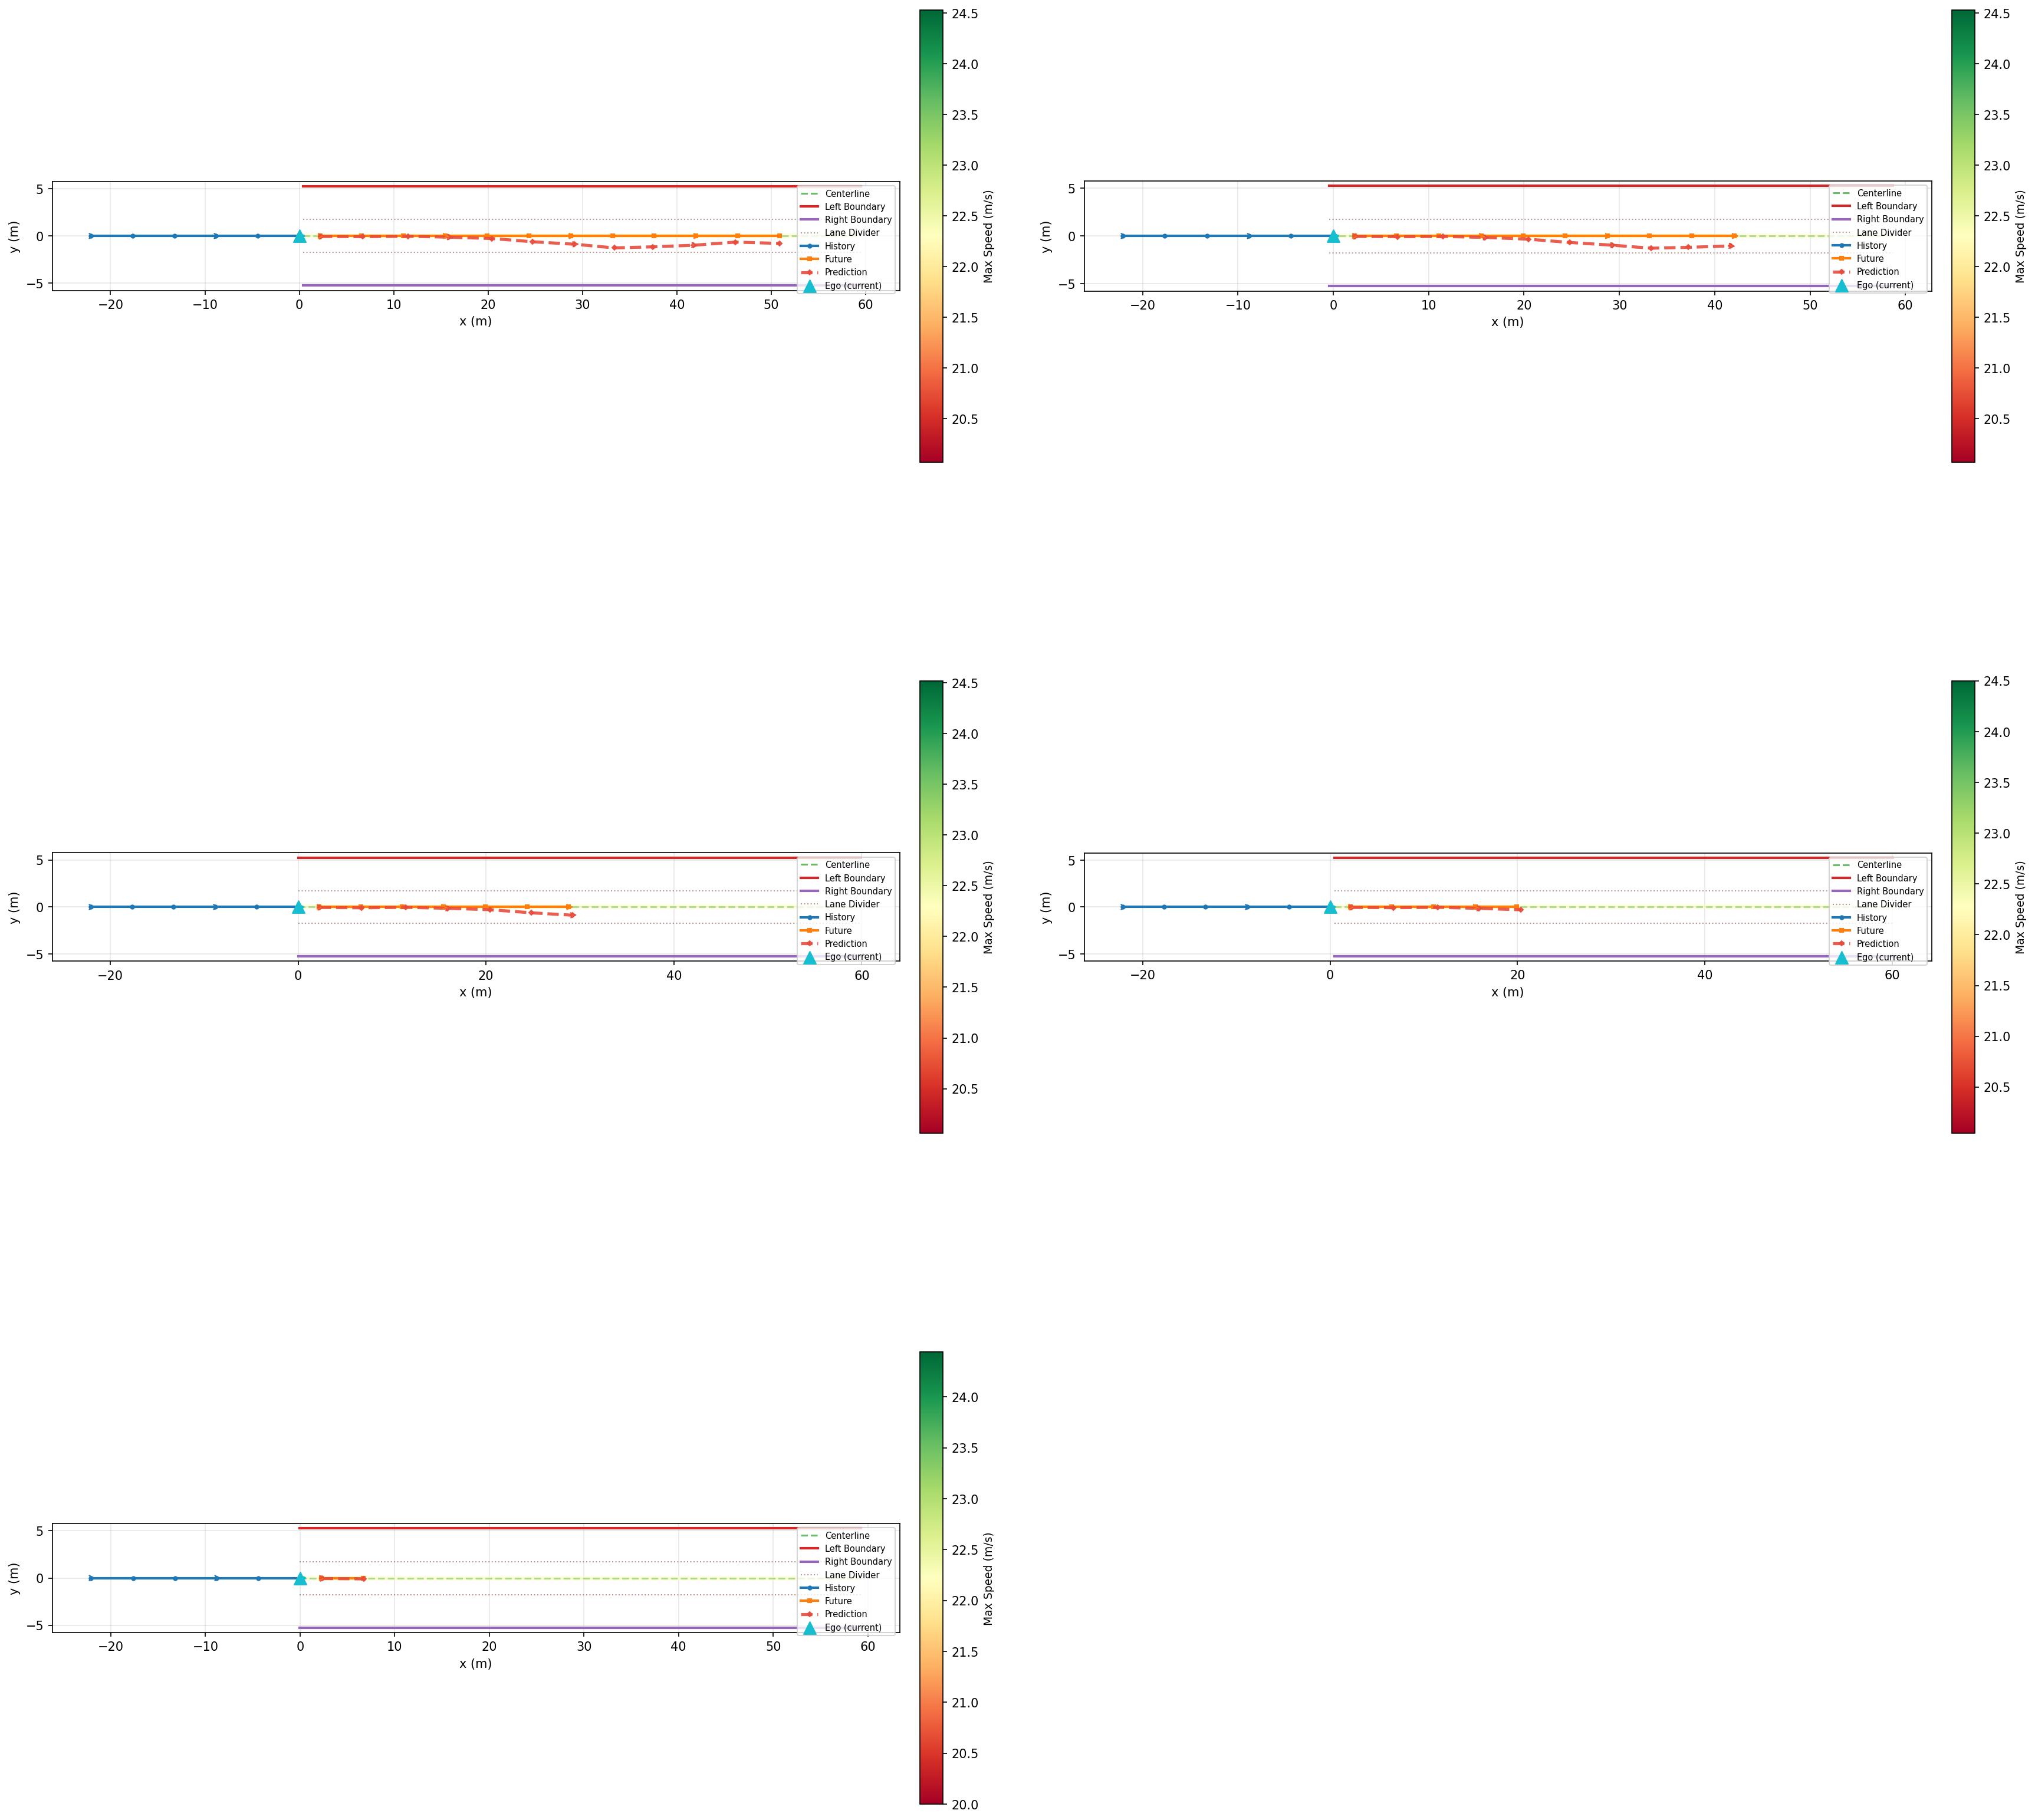

In [4]:
# result[0]["batch"]["future"].shape

batch = result[0]["batch"]
batch["pred_future"]=result[0]["pred_future"]
samples = TrajectoryDatasetVisualizer.batch_to_samples(batch)
print(len(batch)), print(len(samples))
TrajectoryDatasetVisualizer.plot(samples[-5:])


## 检查 batch 结构

In [5]:
from hydra.utils import instantiate

_dm_cfg = il_cfg.trainflow.data
_datamodule = instantiate(_dm_cfg, _recursive_=True)
_datamodule.setup()
train_loader = _datamodule.train_dataloader()
val_loader = _datamodule.val_dataloader()
test_loader = _datamodule.test_dataloader()
print("train/val/test batches:", len(train_loader), len(val_loader), len(test_loader))

 full_ds: 400, train_ds: 320, val_ds: 40, test_ds: 40
train/val/test batches: 5 1 1


In [6]:
# batch = next(iter(train_loader))
print("Batch keys 和 shape:")
for key, val in batch.items():
    print(f"  {key:25s}: {val.shape}  dtype={val.dtype}")

print(f"\nvehicle_params 示例 (第一个样本):")
print(f"  [a_max, omega_max, v_max, wheelbase, length, width, height,")
print(f"   front_overhang, rear_overhang, mass, drag_coeff]")
print(f"  {batch['vehicle_params'][0].numpy()}")

Batch keys 和 shape:
  vehicle_params           : torch.Size([40, 11])  dtype=torch.float32
  history                  : torch.Size([40, 6, 7])  dtype=torch.float32
  history_mask             : torch.Size([40, 6])  dtype=torch.bool
  centerline               : torch.Size([40, 60, 2])  dtype=torch.float32
  centerline_mask          : torch.Size([40, 60])  dtype=torch.bool
  left_boundary            : torch.Size([40, 60, 2])  dtype=torch.float32
  left_boundary_mask       : torch.Size([40, 60])  dtype=torch.bool
  right_boundary           : torch.Size([40, 60, 2])  dtype=torch.float32
  right_boundary_mask      : torch.Size([40, 60])  dtype=torch.bool
  lane_dividers            : torch.Size([40, 2, 60, 2])  dtype=torch.float32
  lane_dividers_mask       : torch.Size([40, 2, 60])  dtype=torch.bool
  future                   : torch.Size([40, 25, 4])  dtype=torch.float32
  future_mask              : torch.Size([40, 25])  dtype=torch.bool
  max_v                    : torch.Size([40, 60])  dt